載入預處理數據...
執行時間切分 (Train: 2019-2023, Test: 2024)...
Train size: 66001, Test size: 13549
Train Defaulters: 3359 (0.0509)

Training Benchmark Model (L2 Ridge)...
Evaluating on 2024 OOT Test Set...

[Benchmark Results (2024 OOT)]
AUC:   0.5990
AP:    0.0628
Brier: 0.2393


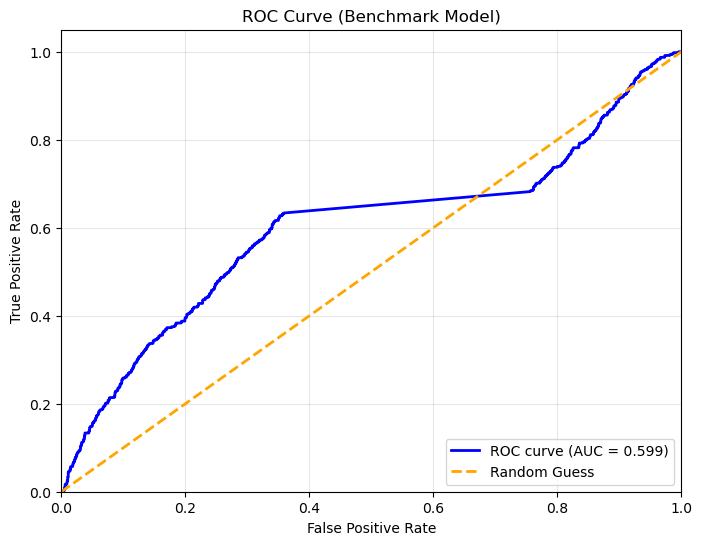

ROC Curve 已儲存至 results/benchmark_roc_curve.png


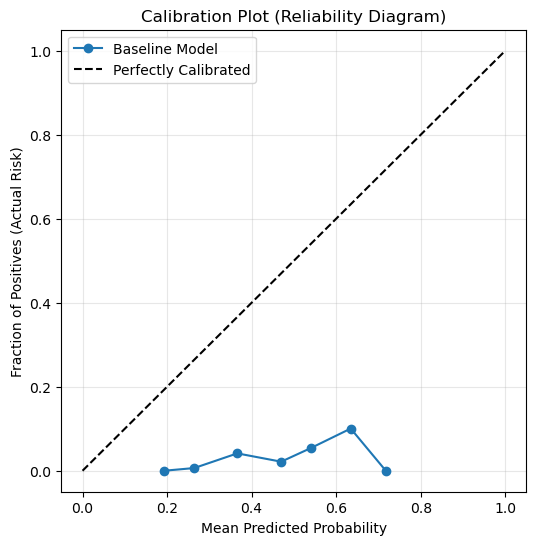

Calibration Plot 已儲存至 results/benchmark_calibration_plot.png

Benchmark 流程全部完成。


In [10]:
# 2_test_benchmark.ipynb
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, roc_curve, auc
from sklearn.calibration import calibration_curve

# --- 設定路徑 ---
BASE_DIR = r"C:\Users\User-NB\OneDrive\Desktop\ML"
DATA_PATH = os.path.join(BASE_DIR, "processed_data", "data_processed.pkl")
RESULT_DIR = os.path.join(BASE_DIR, "results")
os.makedirs(RESULT_DIR, exist_ok=True)

# 1. 載入數據
print("載入預處理數據...")
data = joblib.load(DATA_PATH)
X, y, fyear = data["X"], data["y"], data["fyear"]

# 2. 切分 (Time-Based Split, 符合 PPT Page 10)
print("執行時間切分 (Train: 2019-2023, Test: 2024)...")
train_mask = (fyear >= 2019) & (fyear <= 2023)
test_mask = (fyear == 2024)

X_train, y_train = X[train_mask], y[train_mask]
X_test, y_test = X[test_mask], y[test_mask]

print(f"Train size: {len(y_train)}, Test size: {len(y_test)}")
print(f"Train Defaulters: {y_train.sum()} ({y_train.mean():.4f})")

# 3. 訓練 Benchmark (L2 Ridge) - 符合 PPT Page 12 要求
# - Penalized logistic regression (L2 / Ridge)
# - class_weight='balanced'
print("\nTraining Benchmark Model (L2 Ridge)...")
benchmark_model = LogisticRegression(
    penalty='l2',               # L2 Regularization (Ridge)
    class_weight='balanced',    # Address class imbalance
    solver='liblinear',
    random_state=42
)
benchmark_model.fit(X_train, y_train)

# 4. 評估與指標計算
print("Evaluating on 2024 OOT Test Set...")
y_prob = benchmark_model.predict_proba(X_test)[:, 1]

# 計算指標
roc_auc = roc_auc_score(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
brier = brier_score_loss(y_test, y_prob)

print(f"\n[Benchmark Results (2024 OOT)]")
print(f"AUC:   {roc_auc:.4f}")
print(f"AP:    {ap:.4f}")
print(f"Brier: {brier:.4f}")

# --- 5. 繪圖 (Visualization) ---

# (A) ROC Curve (PPT Page 13)
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='orange', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Benchmark Model)')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
# 存檔供 PPT 使用
plt.savefig(os.path.join(RESULT_DIR, "benchmark_roc_curve.png"))
plt.show()
print("ROC Curve 已儲存至 results/benchmark_roc_curve.png")

# (B) Calibration Plot (PPT Page 14)
prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
plt.figure(figsize=(6, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Baseline Model')
plt.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')
plt.title("Calibration Plot (Reliability Diagram)")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives (Actual Risk)")
plt.legend()
plt.grid(True, alpha=0.3)
# 存檔供 PPT 使用
plt.savefig(os.path.join(RESULT_DIR, "benchmark_calibration_plot.png"))
plt.show()
print("Calibration Plot 已儲存至 results/benchmark_calibration_plot.png")

# 6. 存檔模型與結果
joblib.dump({
    "y_test": y_test, 
    "y_prob": y_prob, 
    "model": benchmark_model,
    "metrics": {"auc": roc_auc, "ap": ap, "brier": brier}
}, os.path.join(RESULT_DIR, "bench_results.pkl"))

print("\nBenchmark 流程全部完成。")